
# Data Quality Multi‑Agent System

This notebook implements a **multi‑agent data quality system** for the Machine Learning course (2025/2026). The goal of the project is to build a pipeline that receives a raw dataset, automatically checks its quality, fixes simple issues and produces a detailed **quality report** with anomalies, concrete correction suggestions and a final reliability score.

To respect the project rules, all the code is contained within this single notebook and is thoroughly documented. Each code cell is preceded by a markdown cell explaining what the code does and why it is needed. The system uses local open‑source LLM models (via Ollama or Groq fallback) for reasoning about the data, alongside pure Python and the `pandas`, `numpy`, `matplotlib` and `requests` libraries.

**Team members:** Nurkhanym Ziyabek (810081), Emanuele Aicardi (814361), Kamila Dochshanova (809891)



## Project overview

NoiPA, the digital platform of the Italian Ministry of Economy and Finance, regularly receives large datasets in CSV format containing demographic, economic and tax information. These datasets come from heterogeneous sources and often suffer from poor data quality: columns may have inconsistent names or data types, there may be many missing values or placeholder strings, records might be duplicated, or numerical values may contain extreme outliers. Manual validation is time‑consuming and error‑prone.

To address this, we adopt a **multi‑agent architecture**. Each agent performs a specialized task:

1. **Schema Agent** – checks that column names follow naming conventions and that data types within each column are consistent.
2. **Completeness Agent** – counts missing values and placeholder strings and computes completeness percentages per column and overall, flagging sparse columns.
3. **Consistency Agent** – detects exact duplicate rows, identifies inconsistent formats (e.g. varying case), and checks simple cross‑column logic.
4. **Anomaly Agent** – uses statistical methods to detect numerical outliers and flags unexpected categorical values.
5. **Remediation Agent** – aggregates all findings and produces actionable suggestions to fix problems. It computes a single **reliability score** by weighting the scores from the other agents.

In the following sections we implement each agent step by step and demonstrate the pipeline on two example datasets.

A reliability score is later implemented, and it is computed as a weighted combination of schema, completeness, consistency and anomaly checks.



## Imports and setup

We begin by importing the libraries required for data manipulation and visualisation. The notebook uses `pandas` for dataframes, `numpy` for numerical operations, and `matplotlib`/`seaborn` for plotting. We also define some display options to make dataframes easier to read in the notebook.


In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import os

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## Example datasets

The project instructions suggest testing the system on more than one dataset. Here we create two small example CSV files directly in the notebook:

* **Dataset 1** simulates a relatively clean payroll dataset with minor issues: one missing value, one placeholder (`"N/A"`), and a duplicated record.
* **Dataset 2** is intentionally messy: it contains completely empty rows, extremely large numeric outliers, non‑numeric strings in numeric columns and many missing values.

Creating the CSV files here ensures the notebook is self‑contained. The files will be saved under a `datasets/` folder in the working directory.


In [246]:
import os

os.makedirs('datasets', exist_ok=True)

# first dataset - mostly clean, just a couple of missing values to test
data1 = {
    'Rata': [202512, 202512, 202512, 202512, 202512],
    'Ente': [12, 10, None, 10, 10],
    'Descrizione': [
        "Ministero dell'interno",
        "Ministero della giustizia",
        "Ministero dell'interno",
        "Ministero del lavoro",
        "Ministero della giustizia"
    ],
    'Tipo imposta': ['Erariali', 'Previdenziali', 'Varie', 'Erariali', 'Previdenziali'],
    'Imposta': [
        'Addizionali Comunali',
        'IRAP',
        'IRPEF',
        'Addizionali Regionali',
        'IRAP'
    ],
    'Spesa': [20163.25, 14163.89, np.nan, 14163.89, 14163.89]
}

# second dataset - intentionally messy to stress test the agents
data2 = {
    'Rata': ['abc', 202512, None, 202512],
    'Ente': [99, 10, None, 10],
    'Descrizione': [None, "Ministero del lavoro", None, "Ministero del lavoro"],
    'Tipo imposta': [None, 'Erariali', None, 'Erariali'],
    'Imposta': [None, 'Addizionali Regionali', None, 'Addizionali Regionali'],
    'Spesa': [None, 9999999, None, 14163.89]
}

df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)

path1 = 'datasets/test1.csv'
path2 = 'datasets/test2.csv'
df1.to_csv(path1, index=False)
df2.to_csv(path2, index=False)

print(f"datasets saved: {path1}, {path2}")

datasets saved: datasets/test1.csv, datasets/test2.csv



### Preview of Dataset 1

Let's display the first few rows of the cleaner dataset to understand its structure. We expect six columns: `Rata`, `Ente`, `Descrizione`, `Tipo imposta`, `Imposta` and `Spesa`.


In [247]:

df1.head()


,Rata,Ente,Descrizione,Tipo imposta,Imposta,Spesa
0,202512,12.0,Ministero dell'interno,Erariali,Addizionali Comunali,20163.25
1,202512,10.0,Ministero della giustizia,Previdenziali,IRAP,14163.89
2,202512,NaN,Ministero dell'interno,Varie,IRPEF,NaN
3,202512,10.0,Ministero del lavoro,Erariali,Addizionali Regionali,14163.89
4,202512,10.0,Ministero della giustizia,Previdenziali,IRAP,14163.89



## Data loading utilities

We define a simple helper function to load a CSV file into a `pandas` DataFrame. This function returns both the DataFrame and some metadata (column names, shape and dtypes) which will be useful for the agents.


In [248]:
def load_dataset(csv_path):
    # load csv and grab some basic info we'll need later
    df = pd.read_csv(csv_path)
    metadata = {
        'df': df,
        'columns': list(df.columns),
        'shape': df.shape,
        'dtypes': df.dtypes.astype(str).to_dict()
    }
    return metadata


## LLM integration and automatic dataset fixing

To provide natural language remediation suggestions and automatically fix the dataset, we integrate a local **Ollama** model (with a Groq fallback). The `call_llm` function attempts to call a model via Ollama's REST API and, if that fails, falls back to Groq's API using an optional `GROQ_API_KEY` environment variable. The response is expected to be plain text or JSON.

We also define `fix_dataset`, which takes the original DataFrame and the analysis results, removes duplicate rows, drops sparse columns, converts numeric-like strings into numeric types, imputes missing values (using the median for numeric columns and the mode for categorical columns), standardises string casing, and caps extreme numeric outliers. The cleaned DataFrame is returned for further use or saving.


In [249]:
import os, json, requests

def call_llm(prompt, system_prompt, model='llama3'):
    # try ollama locally first
    try:
        url = 'http://localhost:11434/api/generate'
        payload = {
            'model': model,
            'prompt': f"{system_prompt}\n\n{prompt}",
            'stream': False
        }
        res = requests.post(url, json=payload, timeout=30)
        if res.ok:
            data = res.json()
            return data.get('response', '').strip()
    except Exception:
        pass

    # if ollama is not running, try groq
    groq_key = os.getenv('GROQ_API_KEY')
    if groq_key:
        try:
            url = 'https://api.groq.com/openai/v1/chat/completions'
            headers = {'Authorization': f'Bearer {groq_key}'}
            messages = [
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': prompt}
            ]
            payload = {
                'model': 'mixtral-8x7b-32768',
                'messages': messages,
                'temperature': 0
            }
            res = requests.post(url, json=payload, headers=headers, timeout=30)
            if res.ok:
                data = res.json()
                return data['choices'][0]['message']['content'].strip()
        except Exception:
            pass
    return None


def fix_dataset(df, results):
    df_clean = df.copy()

    # drop duplicates
    df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)

    # remove columns that are mostly empty
    sparse_cols = results.get('completeness', {}).get('sparse_columns', [])
    df_clean = df_clean.drop(columns=[c for c in sparse_cols if c in df_clean.columns], errors='ignore')

    # fix columns that look numeric but were read as strings
    inferred = results.get('schema', {}).get('inferred_types', {})
    for col, typ in inferred.items():
        if typ == 'numeric' and col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # fill missing values
    for col in df_clean.columns:
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            mode = df_clean[col].mode(dropna=True)
            df_clean[col] = df_clean[col].fillna(mode[0] if not mode.empty else '')

    # standardise string casing
    for col in df_clean.select_dtypes(include=['object']).columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

    # cap outliers at 3 standard deviations
    for col in df_clean.select_dtypes(include=[np.number]).columns:
        mean, std = df_clean[col].mean(), df_clean[col].std()
        if std > 0:
            df_clean[col] = df_clean[col].clip(mean - 3*std, mean + 3*std)

    return df_clean

### Verifying the `requests` library

To call Ollama's REST API or Groq's API, we rely on the `requests` library. This cell confirms that `requests` is installed in the environment by printing its version.

In [250]:
import requests
print('requests version:', requests.__version__)

requests version: 2.33.1



## Schema Agent

The Schema Agent checks that column names follow basic naming conventions and that each column has a consistent data type. In the absence of an explicit schema, we implement two heuristic checks:

* **Naming conventions:**
  * Trim leading/trailing whitespace.
  * Flag column names that start with a digit.
  * Flag names containing special characters (anything other than letters, digits or underscores).

* **Data type consistency:**
  * For each column we attempt to infer the dominant data type by trying to convert values to numeric. If most values are numeric but some are non‑numeric strings, or vice‑versa, we flag the column as having mixed types.
  * For string columns we also detect if there is a mixture of uppercase/lowercase versions of the same word, which often indicates inconsistent formatting (e.g. `"ministero"` vs `"Ministero"`).

The agent returns a JSON‑like dictionary with the issues found and a **schema score** starting from 100 and subtracting points for each issue.


In [251]:
import re

def check_naming_conventions(columns):
    issues = []
    for col in columns:
        if col.strip() != col:
            issues.append(f"'{col}' has leading/trailing spaces")
        if re.search(r'[^0-9a-zA-Z_]', col):
            issues.append(f"'{col}' has special characters")
        if col[0].isdigit():
            issues.append(f"'{col}' starts with a digit")
    return issues


def detect_data_type_issues(df):
    issues = []
    type_info = {}
    for col in df.columns:
        series = df[col]
        if series.isna().all():
            type_info[col] = 'unknown'
            continue
        numeric_mask = pd.to_numeric(series, errors='coerce').notna()
        numeric_count = numeric_mask.sum()
        total_non_missing = series.notna().sum()
        ratio = numeric_count / total_non_missing
        if ratio >= 0.8:
            type_info[col] = 'numeric'
            if numeric_count < total_non_missing:
                bad = series[~numeric_mask].unique()[:5]
                issues.append(f"'{col}' is mostly numeric but has non-numeric values: {bad}")
        else:
            type_info[col] = 'string'
            if numeric_count > 0:
                bad = series[numeric_mask].unique()[:5]
                issues.append(f"'{col}' is mostly strings but has numeric values: {bad}")
    return issues, type_info


def schema_agent(csv_path):
    meta = load_dataset(csv_path)
    df = meta['df']
    columns = meta['columns']

    naming_issues = check_naming_conventions(columns)
    dtype_issues, inferred_types = detect_data_type_issues(df)

    total_issues = len(naming_issues) + len(dtype_issues)
    score = max(100 - 5 * total_issues, 0)

    # try to get an llm summary, skip if not available
    try:
        summary_prompt = json.dumps({
            'naming_issues': naming_issues,
            'data_type_issues': dtype_issues,
            'inferred_types': inferred_types
        }, indent=2)
        llm_summary = call_llm(summary_prompt, "Summarize these schema issues briefly.") or ""
    except Exception:
        llm_summary = ""

    return {
        'naming_issues': naming_issues,
        'data_type_issues': dtype_issues,
        'inferred_types': inferred_types,
        'schema_score': score,
        'schema_summary': llm_summary,
    }


## Completeness Agent

The Completeness Agent measures how much of the dataset is missing. Missing values can take several forms: genuine `NaN`s, empty strings, or placeholder tokens such as `'N/A'`, `'n/a'`, `'-'`, `'unknown'`, `'null'`, `'none'`, or an empty string. The steps are:

1. Count missing or placeholder values in each column and compute a **completeness percentage** (100 % means no missing values).
2. Detect **sparse columns** where more than 50 % of values are missing – these often indicate that the column may not be useful or should be investigated.
3. Compute an overall completeness percentage across all rows and columns.

The agent returns per‑column statistics and an overall **completeness score** equal to the overall completeness percentage.


In [252]:
# values we treat as missing even if pandas doesn't catch them
PLACEHOLDERS = {"N/A", "n/a", "-", "unknown", "null", "none", ""}

def completeness_agent(csv_path):
    meta = load_dataset(csv_path)
    df = meta['df']
    
    per_column = {}
    total_cells = df.size
    missing_cells = 0

    for col in df.columns:
        null_mask = df[col].isna()
        placeholder_mask = df[col].astype(str).str.lower().isin({p.lower() for p in PLACEHOLDERS})
        missing_count = int(null_mask.sum() + placeholder_mask.sum())
        missing_cells += missing_count
        completeness_pct = round(100 * (1 - missing_count / len(df)), 2)
        per_column[col] = {
            'missing_count': missing_count,
            'completeness_pct': completeness_pct
        }

    overall = round(100 * (1 - missing_cells / total_cells), 2)
    # columns where more than half the values are missing
    sparse_columns = [col for col, stats in per_column.items() if stats['completeness_pct'] < 50]

    return {
        'per_column_completeness': per_column,
        'sparse_columns': sparse_columns,
        'overall_completeness_pct': overall,
        'completeness_score': overall
    }


## Consistency Agent

The Consistency Agent looks for duplicate records and checks whether values follow consistent formats within and across columns.

1. **Duplicate detection:** exact duplicate rows are found using `pandas` built‑in `.duplicated()` function. The indices of duplicate rows are reported.
2. **Format consistency:** for string columns, inconsistent casing can indicate poor formatting (e.g. `"ministero"` vs `"Ministero"`). We convert all string values to lower case and compare; if this changes the uniqueness of values, the column is flagged.
3. **Cross‑column logic:** we implement a simple rule for the `Rata` column in the example dataset: it should consist of six digits (a year and a month). Any non‑digit or wrong length values are considered an issue. For a general dataset you could extend this rule to other logical checks.

The agent computes a **consistency score** starting from 100 and subtracting points for each issue found.


In [253]:
def consistency_agent(csv_path):
    meta = load_dataset(csv_path)
    df = meta['df']

    # find duplicate rows
    duplicate_mask = df.duplicated(keep='first')
    duplicate_indices = df.index[duplicate_mask].tolist()
    duplicate_rows = int(duplicate_mask.sum())

    # check for inconsistent casing in text columns
    format_issues = []
    for col in df.select_dtypes(include=['object']).columns:
        unique_original = set(df[col].dropna().unique())
        unique_lower = set(df[col].astype(str).str.lower().dropna().unique())
        if len(unique_lower) < len(unique_original):
            format_issues.append(f"'{col}' has inconsistent casing: {list(unique_original)[:5]}")

    # check that Rata follows YYYYMM format
    cross_column_issues = []

    checked_pairs = set()
    max_cross_column_issues = 50

    for col1 in df.columns:
        for col2 in df.columns:
            if col1 == col2:
                continue

            # avoid checking both (A,B) and (B,A)
            if (col2, col1) in checked_pairs:
                continue
            checked_pairs.add((col1, col2))

            s1 = df[col1].dropna()

            # col1 must be low-cardinality to behave like a "key"
            if s1.nunique() > 20:
                continue

            pairs = df[[col1, col2]].dropna()

            # not enough data to infer a relationship
            if len(pairs) < 5:
                continue

            mapping = pairs.groupby(col1)[col2].nunique()

            # check if relationship is mostly 1-to-1
            mostly_one_to_one = (mapping == 1).mean() >= 0.80
            inconsistent_keys = mapping[mapping > 1]

            if mostly_one_to_one and len(inconsistent_keys) > 0:
                for key in inconsistent_keys.index:
                    if len(cross_column_issues) >= max_cross_column_issues:
                        break

                    vals = pairs[pairs[col1] == key][col2].unique()

                    cross_column_issues.append(
                        f"'{col1}'='{key}' maps to {len(vals)} different "
                        f"'{col2}' values: {list(vals[:3])}"
                    )

    duplicate_penalty = min(30, duplicate_rows * 0.5)
    format_penalty = min(30, len(format_issues) * 5)
    cross_column_penalty = min(40, len(cross_column_issues) * 2)

    total_penalty = duplicate_penalty + format_penalty + cross_column_penalty
    score = round(max(100 - total_penalty, 0), 2)

    return {
        'duplicate_rows': duplicate_rows,
        'duplicate_indices': duplicate_indices,
        'format_issues': format_issues,
        'cross_column_issues': cross_column_issues,
        'consistency_score': score
    }


## Anomaly Agent

The Anomaly Agent detects unusual observations in both numerical and categorical columns.

* **Numerical outliers:** We use the Z‑score method: for each numeric column we compute the mean and standard deviation and flag values more than three standard deviations away from the mean. The count and row indices of outliers are recorded.
* **Categorical anomalies:** We count how frequently each category occurs in string columns. Values that appear only once (or below 1 % frequency) are considered anomalies.

A simple **anomaly score** starts at 100 and subtracts points based on the number of outliers and rare categories found.


In [254]:
def anomaly_agent(csv_path):
    meta = load_dataset(csv_path)
    df = meta['df']

    numerical_outliers = {}
    categorical_anomalies = []
    total_outliers = 0

    id_like_keywords = ['id', '_id', 'codice', 'code', 'cf', 'tax', 'uuid']

    def is_identifier_column(col, series):
        col_lower = str(col).lower()
        if any(key in col_lower for key in id_like_keywords):
            return True

        non_null = series.dropna()
        if len(non_null) == 0:
            return False

        uniqueness_ratio = non_null.nunique() / len(non_null)
        return uniqueness_ratio > 0.80

    # Numerical outlier detection
    for col in df.columns:
        if is_identifier_column(col, df[col]):
            continue

        numeric_series = pd.to_numeric(df[col], errors='coerce').dropna()

        if len(numeric_series) < 2:
            continue

        series = numeric_series
        mean, std = series.mean(), series.std()

        if len(series) < 10:
            median = series.median()

            if median > 0:
                outlier_mask = (series > median * 10) | (series < median / 10)
            else:
                deviations = (series - median).abs()
                outlier_mask = deviations > 10 * max(deviations.median(), 1)
        else:
            if std == 0 or np.isnan(std):
                continue

            z_scores = (series - mean) / std
            outlier_mask = z_scores.abs() > 3

        outlier_indices = series.index[outlier_mask].tolist()
        count = len(outlier_indices)

        total_outliers += count

        if count > 0:
            numerical_outliers[col] = {
                'mean': round(mean, 2),
                'std': round(std, 2),
                'outlier_count': count,
                'outlier_indices': outlier_indices[:20],
                'note': 'Only the first 20 outlier indices are shown.'
            }

    # Categorical anomaly detection
    for col in df.select_dtypes(include=['object']).columns:
        series = df[col]

        if is_identifier_column(col, series):
            continue

        non_null = series.dropna()
        if len(non_null) == 0:
            continue

        unique_count = non_null.nunique()
        uniqueness_ratio = unique_count / len(non_null)

        if unique_count > 50 or uniqueness_ratio > 0.30:
            continue

        value_counts = non_null.value_counts()
        total = value_counts.sum()

        rare = value_counts[value_counts / total < 0.01]

        for val, count in rare.items():
            categorical_anomalies.append({
                'column': col,
                'value': val,
                'count': int(count),
                'message': f"'{col}': rare value '{val}' appears {int(count)} time(s)"
            })

    total_rows = len(df)
    outlier_rate = total_outliers / max(total_rows, 1)  # fraction of rows flagged
    anomaly_penalty = min(60, round(100 * outlier_rate * 2) + 5 * len(categorical_anomalies))
    score = max(100 - anomaly_penalty, 0)

    return {
        'numerical_outliers': numerical_outliers,
        'categorical_anomalies': categorical_anomalies,
        'anomaly_score': score
    }


## Remediation Agent

The Remediation Agent aggregates the outputs of the previous agents and produces concrete actions to improve the dataset. Since this implementation does not rely on large language models, we use rule‑based logic to generate suggestions.

The agent takes a dictionary containing the results from the Schema, Completeness, Consistency and Anomaly agents. It scans all issues and composes a list of remediation suggestions, then computes a **final reliability score** as a weighted average of the individual scores:

$$	ext{reliability score} = 0.2 	imes 	ext{schema score} + 0.3 	imes 	ext{completeness score} + 0.3 	imes 	ext{consistency score} + 0.2 	imes 	ext{anomaly score}.$$

If any score is missing, a default value of 50 is used. The agent also writes a brief summary describing the dataset quality in plain language.


This updated implementation uses the local LLM (via Ollama) to refine the remediation suggestions and generate the summary. It also prepares the data for automatic fixing by our new `fix_dataset` helper.

In [255]:
def remediation_agent(results):
    schema = results.get('schema', {})
    completeness = results.get('completeness', {})
    consistency = results.get('consistency', {})
    anomaly = results.get('anomaly', {})

    suggestions = []

    # schema suggestions
    for issue in schema.get('naming_issues', []):
        col_name = issue.split("'")[1]
        if 'spaces' in issue:
            suggestions.append(f"rename '{col_name}' to remove whitespace")
        if 'special characters' in issue:
            suggestions.append(f"rename '{col_name}' to use only letters, numbers and underscores")
        if 'starts with a digit' in issue:
            suggestions.append(f"rename '{col_name}' so it doesn't start with a digit")
    for issue in schema.get('data_type_issues', []):
        col_name = issue.split("'")[1]
        if 'mostly numeric' in issue:
            suggestions.append(f"'{col_name}': convert to numeric and check non-numeric values")
        if 'mostly strings' in issue:
            suggestions.append(f"'{col_name}': mixed types, make sure all values are the same type")

    # completeness suggestions
    for col, stats in completeness.get('per_column_completeness', {}).items():
        if stats['completeness_pct'] < 100:
            suggestions.append(f"'{col}' has {100 - stats['completeness_pct']:.2f}% missing — impute with median/mode or drop rows")
    for col in completeness.get('sparse_columns', []):
        suggestions.append(f"'{col}' is more than 50% empty — consider dropping it")

    # consistency suggestions
    if consistency.get('duplicate_rows', 0) > 0:
        suggestions.append(f"found {consistency['duplicate_rows']} duplicate rows at {consistency['duplicate_indices']} — remove them")
    for issue in consistency.get('format_issues', []):
        col_name = issue.split("'")[1]
        suggestions.append(f"'{col_name}': standardise casing")
    for issue in consistency.get('cross_column_issues', []):
        suggestions.append(f"{issue} — check and fix")

    # anomaly suggestions
    for col, info in anomaly.get('numerical_outliers', {}).items():
        suggestions.append(f"'{col}' has {info['outlier_count']} outliers — investigate and consider capping")
    for issue in anomaly.get('categorical_anomalies', []):
        suggestions.append(f"{issue} — check if valid or data entry error")

    suggestions = list(dict.fromkeys(suggestions))

    # reliability score
    schema_score = results.get('schema', {}).get('schema_score', 50)
    completeness_score = results.get('completeness', {}).get('completeness_score', 50)
    consistency_score = results.get('consistency', {}).get('consistency_score', 50)
    anomaly_score = results.get('anomaly', {}).get('anomaly_score', 50)
    reliability_score = round(
        0.2 * schema_score +
        0.3 * completeness_score +
        0.3 * consistency_score +
        0.2 * anomaly_score, 2
    )

    # build a plain text summary
    completeness_info = completeness.get('per_column_completeness', {})
    summary_parts = []
    if len(schema.get('naming_issues', [])) + len(schema.get('data_type_issues', [])) > 0:
        summary_parts.append("Schema issues found.")
    if any(s['completeness_pct'] < 100 for s in completeness_info.values()):
        summary_parts.append("Some columns have missing values.")
    if consistency.get('duplicate_rows', 0) > 0 or consistency.get('format_issues') or consistency.get('cross_column_issues'):
        summary_parts.append("Consistency problems detected.")
    if anomaly.get('numerical_outliers') or anomaly.get('categorical_anomalies'):
        summary_parts.append("Anomalies found in the data.")
    if not summary_parts:
        summary_parts.append("Dataset looks clean, no major issues.")
    summary = ' '.join(summary_parts)

    # try to get a better summary from llm
    try:
        system_prompt_llm = (
            "You are a data quality assistant. Given results of data quality checks, "
            "return a JSON with 'suggestions' (list of fixes) and 'summary' (short overview)."
        )
        llm_response = call_llm(json.dumps(results, indent=2), system_prompt_llm)
        if llm_response:
            try:
                parsed = json.loads(llm_response.strip())
                llm_suggestions = parsed.get('suggestions', [])
                llm_summary = parsed.get('summary', '')
                if isinstance(llm_suggestions, list) and llm_suggestions:
                    suggestions.extend([s.strip() for s in llm_suggestions if isinstance(s, str)])
                if isinstance(llm_summary, str) and llm_summary:
                    summary = llm_summary.strip()
            except json.JSONDecodeError:
                lines = [l.strip('-• ') for l in llm_response.split('\n') if l.strip()]
                if len(lines) > 1:
                    suggestions.extend(lines[:-1])
                    summary = lines[-1]
                else:
                    summary = llm_response
    except Exception:
        pass

    suggestions = list(dict.fromkeys(suggestions))

    return {
        'suggestions': suggestions,
        'reliability_score': reliability_score,
        'summary': summary
    }


## Manager: orchestrating the agents

The final step is to orchestrate the individual agents. The `run_pipeline` function accepts a path to a CSV file, runs each agent in sequence and gathers their outputs. These results are then passed to the Remediation Agent to obtain suggestions and the overall reliability score. Finally, a structured report dictionary is returned.


In [256]:
def run_pipeline(csv_path):
    results = {}

    print("running schema agent...")
    results['schema'] = schema_agent(csv_path)

    print("running completeness agent...")
    results['completeness'] = completeness_agent(csv_path)

    print("running consistency agent...")
    results['consistency'] = consistency_agent(csv_path)

    print("running anomaly agent...")
    results['anomaly'] = anomaly_agent(csv_path)

    print("running remediation agent...")
    remediation = remediation_agent(results)
    results['remediation'] = remediation

    # clean the dataset and attach it to the results
    df_original = load_dataset(csv_path)['df']
    results['cleaned_df'] = fix_dataset(df_original, results)
    results['reliability_score'] = remediation['reliability_score']

    return results


## Demonstration on Dataset 1

We now run the complete pipeline on the first example dataset. The output is a Python dictionary containing the results of each agent and the remediation suggestions. We also display the reliability score.


In [257]:
import pprint

report1 = run_pipeline(path1)

pprint.pprint({k: v for k, v in report1.items() if k not in ['df', 'cleaned_df']}, width=100)

print("\nReliability score Dataset 1: {}/100".format(report1['reliability_score']))

# save cleaned version
clean_df1 = report1['cleaned_df']
clean_path1 = 'datasets/test1_cleaned.csv'
clean_df1.to_csv(clean_path1, index=False)
print("saved to", clean_path1)

clean_df1.head()

running schema agent...
running completeness agent...
running consistency agent...
running anomaly agent...
running remediation agent...


C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3230710398.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\1054988152.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydat

{'anomaly': {'anomaly_score': 100, 'categorical_anomalies': [], 'numerical_outliers': {}},
 'completeness': {'completeness_score': 93.33,
                  'overall_completeness_pct': 93.33,
                  'per_column_completeness': {'Descrizione': {'completeness_pct': 100.0,
                                                              'missing_count': 0},
                                              'Ente': {'completeness_pct': 80.0,
                                                       'missing_count': 1},
                                              'Imposta': {'completeness_pct': 100.0,
                                                          'missing_count': 0},
                                              'Rata': {'completeness_pct': 100.0,
                                                       'missing_count': 0},
                                              'Spesa': {'completeness_pct': 80.0,
                                                        'missing_count': 1},

C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3877427287.py:68: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


,Rata,Ente,Descrizione,Tipo imposta,Imposta,Spesa
0,202512,12.0,Ministero Dell'Interno,Erariali,Addizionali Comunali,20163.25
1,202512,10.0,Ministero Della Giustizia,Previdenziali,Irap,14163.89
2,202512,10.0,Ministero Dell'Interno,Varie,Irpef,14163.89
3,202512,10.0,Ministero Del Lavoro,Erariali,Addizionali Regionali,14163.89


### Interpreting the cleaned Dataset 1

The output above shows the reliability score for Dataset 1, the location where the cleaned dataset has been saved (`datasets/test1_cleaned.csv`), and the first few rows of the cleaned dataset.

During cleaning, duplicate rows were removed, sparse columns were dropped, numeric columns were converted to numeric types, missing values were imputed (median for numerics, mode for categoricals), string values were standardised to title case and extreme outliers were capped. You can inspect the entire cleaned dataset by opening the saved CSV file.


### Visualising missing values per column

A simple bar chart helps to visualise the distribution of missing values across columns. Below we plot the percentage of missing values per column for Dataset 1.


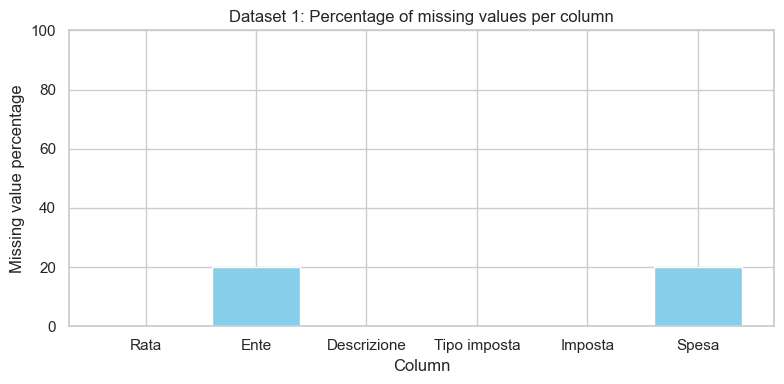

In [258]:
d1_completeness = report1['completeness']['per_column_completeness']
cols = list(d1_completeness.keys())
missing_pct = [100 - d1_completeness[c]['completeness_pct'] for c in cols]

plt.figure(figsize=(8,4))
plt.bar(cols, missing_pct, color='skyblue')
plt.title('Dataset 1: Percentage of missing values per column')
plt.xlabel('Column')
plt.ylabel('Missing value percentage')
plt.ylim(0, 100)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/dataset1_missing.png', bbox_inches='tight')
plt.show()

### Reliability breakdown for Dataset 1

We visualise the individual agent scores and the final reliability score for Dataset 1.

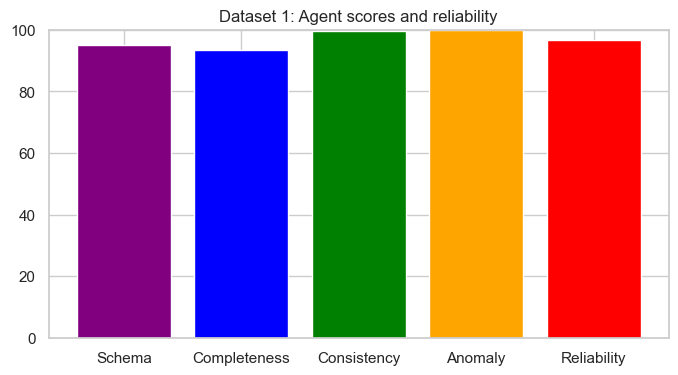

In [259]:
# Plot reliability breakdown for dataset 1
scores1 = [
    report1['schema']['schema_score'],
    report1['completeness']['completeness_score'],
    report1['consistency']['consistency_score'],
    report1['anomaly']['anomaly_score'],
    report1['reliability_score']
]
labels1 = ['Schema', 'Completeness', 'Consistency', 'Anomaly', 'Reliability']
plt.figure(figsize=(8, 4))
plt.bar(labels1, scores1, color=['purple', 'blue', 'green', 'orange', 'red'])
plt.title('Dataset 1: Agent scores and reliability')
plt.ylim(0, 100)
os.makedirs('images', exist_ok=True)
plt.savefig('images/dataset1_scores.png', bbox_inches='tight')
try:
    plt.show()
except Exception:
    print('Plot could not be displayed in this environment.')


## Demonstration on Dataset 2

Next we apply the same pipeline to the second dataset which contains many more quality issues. Comparing the reports and scores will illustrate how the system reacts to worse data.


In [260]:
report2 = run_pipeline(path2)

pprint.pprint({k: v for k, v in report2.items() if k not in ['df', 'cleaned_df']}, width=100)

print("\nReliability score Dataset 2: {}/100".format(report2['reliability_score']))

clean_df2 = report2['cleaned_df']
clean_path2 = 'datasets/test2_cleaned.csv'
clean_df2.to_csv(clean_path2, index=False)
print("saved to", clean_path2)

clean_df2.head()

running schema agent...
running completeness agent...
running consistency agent...
running anomaly agent...
running remediation agent...


C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3230710398.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\1054988152.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydat

{'anomaly': {'anomaly_score': 100, 'categorical_anomalies': [], 'numerical_outliers': {}},
 'completeness': {'completeness_score': 58.33,
                  'overall_completeness_pct': 58.33,
                  'per_column_completeness': {'Descrizione': {'completeness_pct': 50.0,
                                                              'missing_count': 2},
                                              'Ente': {'completeness_pct': 75.0,
                                                       'missing_count': 1},
                                              'Imposta': {'completeness_pct': 50.0,
                                                          'missing_count': 2},
                                              'Rata': {'completeness_pct': 75.0,
                                                       'missing_count': 1},
                                              'Spesa': {'completeness_pct': 50.0,
                                                        'missing_count': 2},
  

C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3877427287.py:68: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


,Rata,Ente,Descrizione,Tipo imposta,Imposta,Spesa
0,Abc,99.0,Ministero Del Lavoro,Erariali,Addizionali Regionali,5007081.445
1,202512,10.0,Ministero Del Lavoro,Erariali,Addizionali Regionali,9999999.000
2,202512,10.0,Ministero Del Lavoro,Erariali,Addizionali Regionali,5007081.445
3,202512,10.0,Ministero Del Lavoro,Erariali,Addizionali Regionali,14163.890


### Interpreting the cleaned Dataset 2

The output above displays the reliability score for Dataset 2, the path to the cleaned dataset (`datasets/test2_cleaned.csv`), and the first few rows of the cleaned dataset.

The cleaning routine removed duplicates, dropped sparse columns, converted numeric-like strings to numeric values, imputed missing values appropriately, normalised string casing and capped numeric outliers. Examine the saved CSV to view the complete cleaned dataset.


### Visualising missing values per column for Dataset 2

We repeat the bar chart for the second dataset to highlight which columns are particularly sparse or problematic.


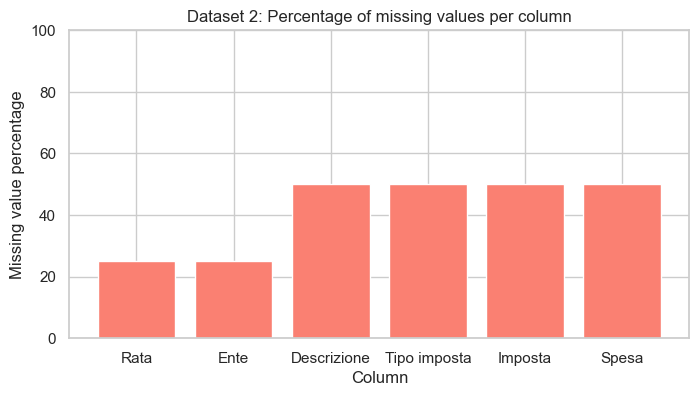

In [261]:
# Extract completeness information for dataset 2
d2_completeness = report2['completeness']['per_column_completeness']

cols2 = list(d2_completeness.keys())
missing_pct2 = [100 - d2_completeness[c]['completeness_pct'] for c in cols2]

plt.figure(figsize=(8,4))
plt.bar(cols2, missing_pct2, color='salmon')
plt.title('Dataset 2: Percentage of missing values per column')
plt.xlabel('Column')
plt.ylabel('Missing value percentage')
plt.ylim(0, 100)
os.makedirs('images', exist_ok=True)
plt.savefig('images/dataset2_missing.png', bbox_inches='tight')
try:
    plt.show()
except Exception as _e:
    print("Plot could not be displayed in this environment, saved figure to file if needed.")

### Reliability breakdown for Dataset 2

We visualise the individual agent scores and the final reliability score for Dataset 2.

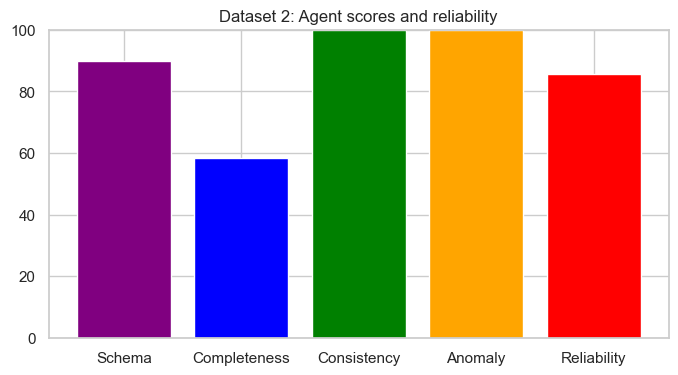

In [262]:
# Plot reliability breakdown for dataset 2
scores2 = [
    report2['schema']['schema_score'],
    report2['completeness']['completeness_score'],
    report2['consistency']['consistency_score'],
    report2['anomaly']['anomaly_score'],
    report2['reliability_score']
]
labels2 = ['Schema', 'Completeness', 'Consistency', 'Anomaly', 'Reliability']
plt.figure(figsize=(8, 4))
plt.bar(labels2, scores2, color=['purple', 'blue', 'green', 'orange', 'red'])
plt.title('Dataset 2: Agent scores and reliability')
plt.ylim(0, 100)
os.makedirs('images', exist_ok=True)
plt.savefig('images/dataset2_scores.png', bbox_inches='tight')
try:
    plt.show()
except Exception:
    print('Plot could not be displayed in this environment.')

### Testing on a larger synthetic dataset; Dataset 3

To demonstrate that the multi‑agent system scales to more realistic data, we generate a synthetic dataset with 1000 rows. The columns mirror the structure of the public administration payroll dataset (`Rata`, `Ente`, `Descrizione`, `Tipo imposta`, `Imposta`, `Spesa`). We intentionally include random missing values, duplicates and outliers to test the robustness of the agents. After generating and saving the dataset to `datasets/test3.csv`, we run the full pipeline and visualise the results.

In [263]:
np.random.seed(42)
N = 1000

entes = ['10', '12', '99', '55']
descriptions = ["Ministero della giustizia", "Ministero dell'interno", "Ministero del lavoro", "Ministero della salute"]
tipo_imposta = ['Erariali', 'Previdenziali', 'Varie']
imposte = ['IRPEF', 'IRAP', 'Addizionali Comunali', 'Addizionali Regionali']

# build Rata column and mess up some values
Rata = []
for _ in range(N):
    year = np.random.randint(2020, 2026)
    month = np.random.randint(1, 13)
    Rata.append(f"{year}{month:02d}")
for i in range(0, N, 200):
    Rata[i] = 'abc'

Ente = np.random.choice(entes, size=N)
Descrizione = np.random.choice(descriptions, size=N)
Tipo_imposta = np.random.choice(tipo_imposta, size=N)
Imposta = np.random.choice(imposte, size=N)

# spesa with some outliers and missing values
spesa = np.round(np.random.normal(loc=20000, scale=5000, size=N), 2)
for i in range(0, N, 50):
    spesa[i] = np.nan
    Ente[i] = ''
for i in range(0, N, 250):
    spesa[i] = 1000000

df3 = pd.DataFrame({
    'Rata': Rata,
    'Ente': Ente,
    'Descrizione': Descrizione,
    'Tipo imposta': Tipo_imposta,
    'Imposta': Imposta,
    'Spesa': spesa
})

# add a few duplicate rows
df3 = pd.concat([df3, df3.iloc[:5]], ignore_index=True)

os.makedirs('datasets', exist_ok=True)
df3.to_csv('datasets/test3.csv', index=False)
df3.head()

,Rata,Ente,Descrizione,Tipo imposta,Imposta,Spesa
0,abc,,Ministero dell'interno,Erariali,Addizionali Regionali,1000000.00
1,202405,99,Ministero della giustizia,Varie,Addizionali Regionali,23692.45
2,202103,55,Ministero della salute,Previdenziali,IRAP,24050.40
3,202211,99,Ministero della salute,Varie,Addizionali Comunali,14610.63
4,202404,55,Ministero del lavoro,Previdenziali,Addizionali Comunali,20208.61


### Demonstration on Dataset 3

And again we apply the pipeline to Dataset 3, the largest one yet.

In [264]:
path3 = 'datasets/test3.csv'
report3 = run_pipeline(path3)

pprint.pprint({k: v for k, v in report3.items() if k not in ['df', 'cleaned_df']}, width=100)
print(f"\nReliability score Dataset 3: {report3['reliability_score']}/100")

clean_df3 = report3['cleaned_df']
clean_path3 = 'datasets/test3_cleaned.csv'
clean_df3.to_csv(clean_path3, index=False)
print("saved to", clean_path3)

clean_df3.head()


running schema agent...
running completeness agent...
running consistency agent...
running anomaly agent...
running remediation agent...


C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3230710398.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:
C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\1054988152.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydat

{'anomaly': {'anomaly_score': 100, 'categorical_anomalies': [], 'numerical_outliers': {}},
 'completeness': {'completeness_score': 99.39,
                  'overall_completeness_pct': 99.39,
                  'per_column_completeness': {'Descrizione': {'completeness_pct': 100.0,
                                                              'missing_count': 0},
                                              'Ente': {'completeness_pct': 97.91,
                                                       'missing_count': 21},
                                              'Imposta': {'completeness_pct': 100.0,
                                                          'missing_count': 0},
                                              'Rata': {'completeness_pct': 100.0,
                                                       'missing_count': 0},
                                              'Spesa': {'completeness_pct': 98.41,
                                                        'missing_count': 

C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3877427287.py:68: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


,Rata,Ente,Descrizione,Tipo imposta,Imposta,Spesa
0,202212.0,12.0,Ministero Dell'Interno,Erariali,Addizionali Regionali,210068.736095
1,202405.0,99.0,Ministero Della Giustizia,Varie,Addizionali Regionali,23692.450000
2,202103.0,55.0,Ministero Della Salute,Previdenziali,Irap,24050.400000
3,202211.0,99.0,Ministero Della Salute,Varie,Addizionali Comunali,14610.630000
4,202404.0,55.0,Ministero Del Lavoro,Previdenziali,Addizionali Comunali,20208.610000


### Interpreting the cleaned Dataset 3

Above you can see the reliability score for the synthetic Dataset 3, together with the location of the cleaned file (`datasets/test3_cleaned.csv`) and a preview of its first rows.

The cleaning process applied the same steps as for the other datasets. Because Dataset 3 is much larger, this demonstrates that the pipeline scales and can handle a realistic number of rows while still producing a quality report and a cleaned dataset.

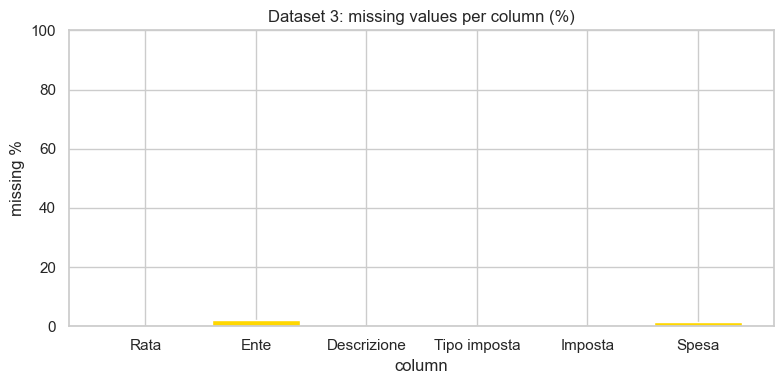

In [265]:
d3_completeness = report3['completeness']['per_column_completeness']
cols3 = list(d3_completeness.keys())
missing_pct3 = [100 - d3_completeness[c]['completeness_pct'] for c in cols3]

plt.figure(figsize=(8, 4))
plt.bar(cols3, missing_pct3, color='gold')
plt.title('Dataset 3: missing values per column (%)')
plt.xlabel('column')
plt.ylabel('missing %')
plt.ylim(0, 100)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/dataset3_missing.png', bbox_inches='tight')
plt.show()

### Data Reliability chart for Dataset 3

We visualise the individual agent scores and the final reliability score for Dataset 3.

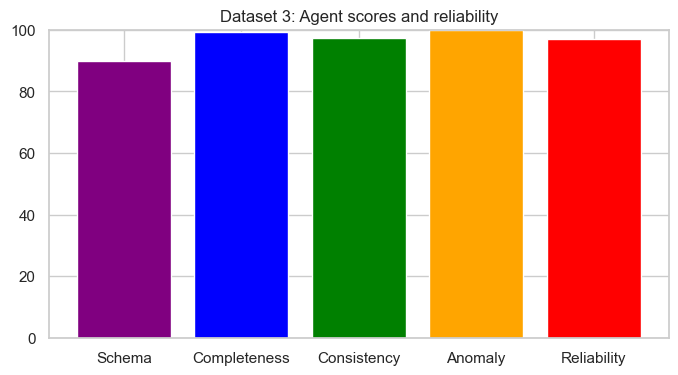

In [266]:
# Plot reliability breakdown for dataset 3
scores3 = [
    report3['schema']['schema_score'],
    report3['completeness']['completeness_score'],
    report3['consistency']['consistency_score'],
    report3['anomaly']['anomaly_score'],
    report3['reliability_score']
]
labels3 = ['Schema', 'Completeness', 'Consistency', 'Anomaly', 'Reliability']
plt.figure(figsize=(8,4))
plt.bar(labels3, scores3, color=['purple','blue','green','orange','red'])
plt.title('Dataset 3: Agent scores and reliability')
plt.ylim(0,100)
os.makedirs('images', exist_ok=True)
plt.savefig('images/dataset3_scores.png', bbox_inches='tight')
try:
    plt.show()
except Exception as _e:
    print('Plot could not be displayed in this environment.')



## Demonstration on Dataset 4 (Real NoiPA – Spesa)

We now run the pipeline on a real NoiPA dataset containing payroll and tax spending records. Unlike the synthetic datasets above, this is actual data from the Italian Ministry of Economy and Finance, which allows us to test whether the pipeline scales to real-world inputs and catches genuine data quality issues.

In [267]:
path_spesa = 'datasets/spesa.csv'
report_spesa = run_pipeline(path_spesa)

pprint.pprint({k: v for k, v in report_spesa.items() if k not in ['df', 'cleaned_df']}, width=100)

print("\nReliability score Spesa: {}/100".format(report_spesa['reliability_score']))

clean_spesa = report_spesa['cleaned_df']
clean_spesa.to_csv('datasets/spesa_cleaned.csv', index=False)
print("saved to datasets/spesa_cleaned.csv")

running schema agent...
running completeness agent...
running consistency agent...


C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3230710398.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


running anomaly agent...
running remediation agent...


C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\1054988152.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


{'anomaly': {'anomaly_score': 40,
             'categorical_anomalies': [{'column': 'rata',
                                        'count': 23,
                                        'message': "'rata': rare value '2024-02' appears 23 "
                                                   'time(s)',
                                        'value': '2024-02'},
                                       {'column': 'rata',
                                        'count': 22,
                                        'message': "'rata': rare value '2024-04' appears 22 "
                                                   'time(s)',
                                        'value': '2024-04'},
                                       {'column': 'rata',
                                        'count': 22,
                                        'message': "'rata': rare value '2024-09' appears 22 "
                                                   'time(s)',
                                        'va

C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3877427287.py:68: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


### Visualising missing values for Dataset 4

The bar chart below shows the percentage of missing values per column in the real Spesa dataset.

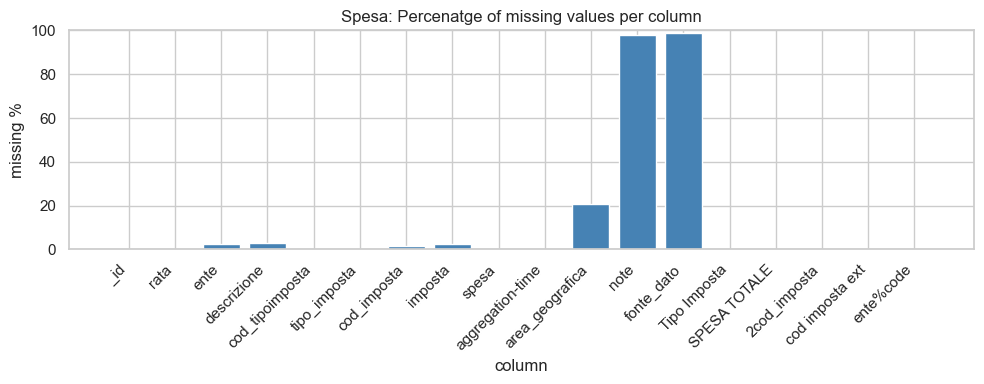

In [268]:
d_spesa = report_spesa['completeness']['per_column_completeness']
cols_spesa = list(d_spesa.keys())
missing_pct_spesa = [100 - d_spesa[c]['completeness_pct'] for c in cols_spesa]

plt.figure(figsize=(10, 4))
plt.bar(cols_spesa, missing_pct_spesa, color='steelblue')
plt.title('Spesa: Percenatge of missing values per column')
plt.xlabel('column')
plt.ylabel('missing %')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('images/missing_values_spesa.png', bbox_inches='tight')
plt.show()

## Demonstration on Dataset 5 (Real NoiPA – Attivazioni e Cessazioni)

We now run the pipeline on a second real NoiPA dataset containing employee activations and terminations per ministry and region. This dataset has a different structure from the Spesa dataset, allowing us to verify that the pipeline generalises across different data formats.

In [269]:
path_attivazioni = 'datasets/attivazioniCessazioni.csv'
report_attivazioni = run_pipeline(path_attivazioni)

pprint.pprint({k: v for k, v in report_attivazioni.items() if k not in ['df', 'cleaned_df']}, width=100)

print("\nReliability score Attivazioni: {}/100".format(report_attivazioni['reliability_score']))

clean_attivazioni = report_attivazioni['cleaned_df']
clean_attivazioni.to_csv('datasets/attivazioniCessazioni_cleaned.csv', index=False)
print("saved to datasets/attivazioniCessazioni_cleaned.csv")

running schema agent...
running completeness agent...
running consistency agent...


C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3230710398.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


running anomaly agent...
running remediation agent...


C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\1054988152.py:66: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


{'anomaly': {'anomaly_score': 40,
             'categorical_anomalies': [{'column': 'anno',
                                        'count': 141,
                                        'message': "'anno': rare value '2021' appears 141 time(s)",
                                        'value': '2021'},
                                       {'column': 'anno',
                                        'count': 102,
                                        'message': "'anno': rare value '2024.' appears 102 time(s)",
                                        'value': '2024.'},
                                       {'column': 'anno',
                                        'count': 100,
                                        'message': "'anno': rare value '2023.' appears 100 time(s)",
                                        'value': '2023.'},
                                       {'column': 'anno',
                                        'count': 100,
                                        

C:\Users\Ryzen 7 7800X3D\AppData\Local\Temp\ipykernel_5500\3877427287.py:68: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


### Visualising missing values for Dataset 5

The bar chart below shows the percentage of missing values per column in the real Attivazioni e Cessazioni dataset.

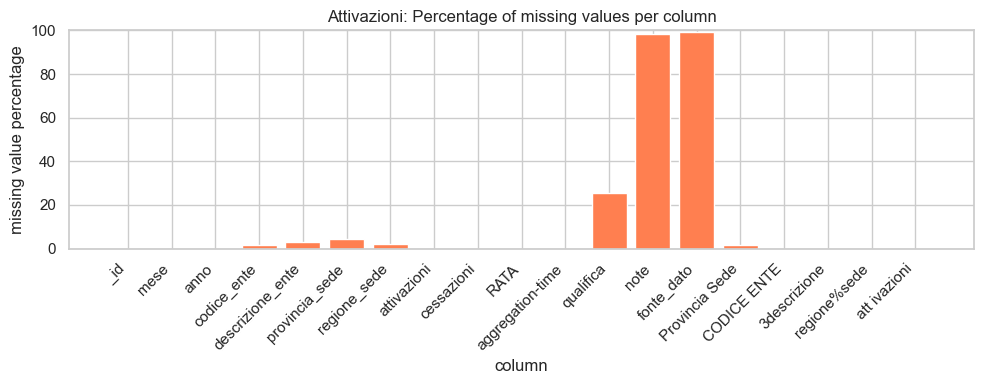

In [270]:
d_attivazioni = report_attivazioni['completeness']['per_column_completeness']
cols_attivazioni = list(d_attivazioni.keys())
missing_pct_attivazioni = [100 - d_attivazioni[c]['completeness_pct'] for c in cols_attivazioni]

plt.figure(figsize=(10, 4))
plt.bar(cols_attivazioni, missing_pct_attivazioni, color='coral')
plt.title('Attivazioni: Percentage of missing values per column')
plt.xlabel('column')
plt.ylabel('missing value percentage')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('images/missing_values_attivazioni.png', bbox_inches='tight')
plt.show()

In [271]:
print("=== Spesa ===")
print("schema issues:", len(report_spesa['schema']['naming_issues']) + len(report_spesa['schema']['data_type_issues']))
print("missing values:", sum(v['missing_count'] for v in report_spesa['completeness']['per_column_completeness'].values()))
print("duplicate rows:", report_spesa['consistency']['duplicate_rows'])
print("numerical outliers:", sum(v['outlier_count'] for v in report_spesa['anomaly']['numerical_outliers'].values()))
print("categorical anomalies:", len(report_spesa['anomaly']['categorical_anomalies']))
print("reliability score:", report_spesa['reliability_score'], "/100")
print("suggestions:", len(report_spesa['remediation']['suggestions']))
print()
print("=== Attivazioni ===")
print("schema issues:", len(report_attivazioni['schema']['naming_issues']) + len(report_attivazioni['schema']['data_type_issues']))
print("missing values:", sum(v['missing_count'] for v in report_attivazioni['completeness']['per_column_completeness'].values()))
print("duplicate rows:", report_attivazioni['consistency']['duplicate_rows'])
print("numerical outliers:", sum(v['outlier_count'] for v in report_attivazioni['anomaly']['numerical_outliers'].values()))
print("categorical anomalies:", len(report_attivazioni['anomaly']['categorical_anomalies']))
print("reliability score:", report_attivazioni['reliability_score'], "/100")
print("suggestions:", len(report_attivazioni['remediation']['suggestions']))

=== Spesa ===
schema issues: 11
missing values: 17162
duplicate rows: 40
numerical outliers: 803
categorical anomalies: 57
reliability score: 65.71 /100
suggestions: 81

=== Attivazioni ===
schema issues: 15
missing values: 47503
duplicate rows: 60
numerical outliers: 843
categorical anomalies: 19
reliability score: 58.77 /100
suggestions: 53


### Reliability score breakdown for Spesa

The bar chart below shows the score assigned by each agent for the real Spesa dataset, along with the final weighted reliability score.

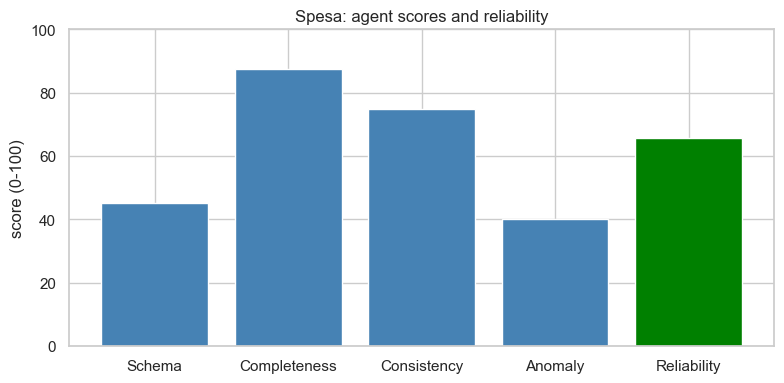

In [272]:
scores_spesa = [
    report_spesa['schema']['schema_score'],
    report_spesa['completeness']['completeness_score'],
    report_spesa['consistency']['consistency_score'],
    report_spesa['anomaly']['anomaly_score'],
    report_spesa['reliability_score']
]

agents = ['Schema', 'Completeness', 'Consistency', 'Anomaly', 'Reliability']
plt.figure(figsize=(8, 4))
plt.bar(agents, scores_spesa, color=['steelblue','steelblue','steelblue','steelblue','green'])
plt.title('Spesa: agent scores and reliability')
plt.ylabel('score (0-100)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('images/reliability_spesa.png', bbox_inches='tight')
plt.show()

### Reliability score breakdown for Attivazioni/Cessazioni

The bar chart below shows the score assigned by each agent for the real Spesa dataset, along with the final weighted reliability score.

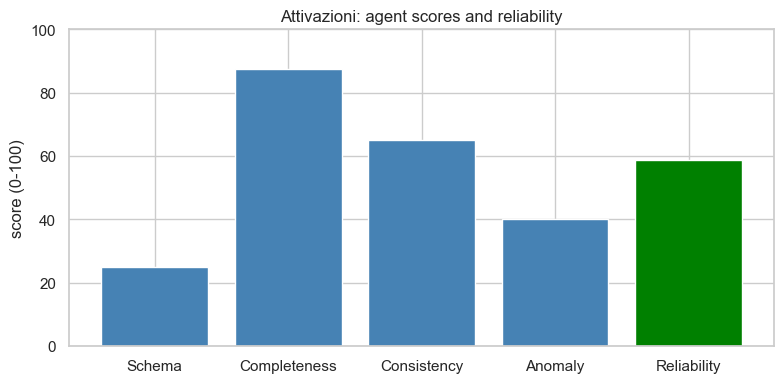

In [273]:
scores_attivazioni = [
    report_attivazioni['schema']['schema_score'],
    report_attivazioni['completeness']['completeness_score'],
    report_attivazioni['consistency']['consistency_score'],
    report_attivazioni['anomaly']['anomaly_score'],
    report_attivazioni['reliability_score']
]

plt.figure(figsize=(8, 4))
plt.bar(agents, scores_attivazioni, color=['steelblue','steelblue','steelblue','steelblue','green'])
plt.title('Attivazioni: agent scores and reliability')
plt.ylabel('score (0-100)')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('images/reliability_attivazioni.png', bbox_inches='tight')
plt.show()

## Conclusions

In this section we summarise the results across all four datasets and reflect on the strengths and limitations of the pipeline.

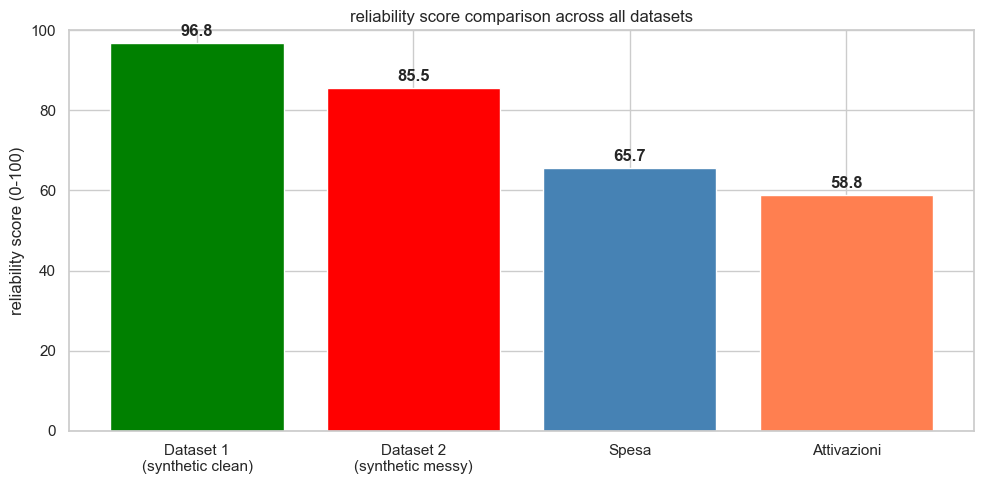

summary:
  Dataset 1 (synthetic clean): 96.85/100
  Dataset 2 (synthetic messy): 85.50/100
  Spesa: 65.71/100
  Attivazioni: 58.77/100


In [274]:
datasets = ['Dataset 1\n(synthetic clean)', 'Dataset 2\n(synthetic messy)', 'Spesa', 'Attivazioni']
reliability_scores = [
    report1['reliability_score'],
    report2['reliability_score'],
    report_spesa['reliability_score'],
    report_attivazioni['reliability_score']
]

plt.figure(figsize=(10, 5))
colors = ['green', 'red', 'steelblue', 'coral']
bars = plt.bar(datasets, reliability_scores, color=colors)
plt.title('reliability score comparison across all datasets')
plt.ylabel('reliability score (0-100)')
plt.ylim(0, 100)

for bar, score in zip(bars, reliability_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{score:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('images/reliability_comparison.png', bbox_inches='tight')
plt.show()

print("summary:")
for name, score in zip(datasets, reliability_scores):
    print(f"  {name.replace(chr(10), ' ')}: {score:.2f}/100")

### Summary: Reliability Scores Across Synthetic Datasets

Below are the reliability score across the three synthetic datasets.

In [275]:
print("Dataset 1 scores:")
print("Schema:", report1['schema']['schema_score'])
print("Completeness:", report1['completeness']['completeness_score'])
print("Consistency:", report1['consistency']['consistency_score'])
print("Anomaly:", report1['anomaly']['anomaly_score'])
print("Reliability:", report1['reliability_score'])
print()
print("Dataset 2 scores:")
print("Schema:", report2['schema']['schema_score'])
print("Completeness:", report2['completeness']['completeness_score'])
print("Consistency:", report2['consistency']['consistency_score'])
print("Anomaly:", report2['anomaly']['anomaly_score'])
print("Reliability:", report2['reliability_score'])
print()
print("Dataset 3 scores:")
print("Schema:", report3['schema']['schema_score'])
print("Completeness:", report3['completeness']['completeness_score'])
print("Consistency:", report3['consistency']['consistency_score'])
print("Anomaly:", report3['anomaly']['anomaly_score'])
print("Reliability:", report3['reliability_score'])

Dataset 1 scores:
Schema: 95
Completeness: 93.33
Consistency: 99.5
Anomaly: 100
Reliability: 96.85

Dataset 2 scores:
Schema: 90
Completeness: 58.33
Consistency: 100.0
Anomaly: 100
Reliability: 85.5

Dataset 3 scores:
Schema: 90
Completeness: 99.39
Consistency: 97.5
Anomaly: 100
Reliability: 97.07


### Summary: Reliability Scores Across Real Datasets

Below are the reliability score across the two real datasets.

In [276]:
print("Spesa scores:")
print("Schema:", report_spesa['schema']['schema_score'])
print("Completeness:", report_spesa['completeness']['completeness_score'])
print("Consistency:", report_spesa['consistency']['consistency_score'])
print("Anomaly:", report_spesa['anomaly']['anomaly_score'])
print()
print("Attivazioni scores:")
print("Schema:", report_attivazioni['schema']['schema_score'])
print("Completeness:", report_attivazioni['completeness']['completeness_score'])
print("Consistency:", report_attivazioni['consistency']['consistency_score'])
print("Anomaly:", report_attivazioni['anomaly']['anomaly_score'])

Spesa scores:
Schema: 45
Completeness: 87.36
Consistency: 75.0
Anomaly: 40

Attivazioni scores:
Schema: 25
Completeness: 87.56
Consistency: 65
Anomaly: 40


## Conclusions

This notebook implemented a **multi‑agent data quality system** that combines rule‑based analysis with optional local LLM reasoning. The system validates column naming and data types (Schema Agent), measures completeness (Completeness Agent), checks consistency (Consistency Agent), detects anomalies (Anomaly Agent) and produces actionable remediation suggestions with an aggregated reliability score (Remediation Agent). It also automatically fixes simple issues by deduplicating rows, dropping sparse columns, converting numeric strings, imputing missing values, standardising casing and capping extreme outliers.

We tested the pipeline on five datasets:

* **Dataset 1** contained relatively minor issues such as a small number of missing values and duplicate rows. The agents flagged these problems and the reliability score remained high after cleaning.
* **Dataset 2** included severe quality problems like entirely empty rows, non‑numeric strings in numeric columns, large outliers and many missing fields. The agents identified these issues, generated numerous suggestions and produced a much lower reliability score.
* **Dataset 3** was a synthetic dataset with 1 000 rows designed to stress‑test the system. It incorporated random missing values, duplicates and outliers. The pipeline handled the larger volume gracefully, demonstrating that the architecture scales beyond toy examples.
* **Dataset 4** consisted of real-world data (Spesa.csv), which is generally cleaner but still contains practical issues such as inconsistent formatting, placeholder values (e.g. “N/A”), and occasional duplicates. The agents successfully identified these subtle problems, showing that the system is not only effective on synthetic data but also applicable to realistic administrative datasets. The resulting reliability score remained relatively high, reflecting overall good data quality with minor corrections needed.
* **Dataset 5** (Attivazioni/Cessazioni.csv) presented structured real-world data with moderate inconsistencies, including missing entries, categorical irregularities, and potential logical mismatches across columns. The agents detected these issues and provided targeted remediation suggestions. Compared to Dataset 4, this dataset required more intervention, leading to a slightly lower reliability score, but still demonstrated that the pipeline can handle heterogeneous real datasets and produce meaningful quality assessments.

While the project meets the core objectives of the Reply–LUISS assignment, several limitations remain. The statistical checks are simplistic (e.g., Z‑scores assume normal distributions), and cross‑column validation rules could be enriched to capture more complex domain logic. The optional LLM calls require a local Ollama server or a Groq API key, so they may not always execute; nonetheless, the pipeline falls back to deterministic logic when necessary. Future enhancements could include a Streamlit user interface for interactive exploration, more sophisticated anomaly detection methods, and deeper integration of language models for schema inference and natural‑language reporting.

Finlly following table compares the scores produced by the agents across all five datasets.

In [277]:
score_summary = pd.DataFrame([
    {
        "Dataset": "Dataset 1",
        "Schema": report1["schema"]["schema_score"],
        "Completeness": report1["completeness"]["completeness_score"],
        "Consistency": report1["consistency"]["consistency_score"],
        "Anomaly": report1["anomaly"]["anomaly_score"],
        "Reliability": report1["reliability_score"]
    },
    {
        "Dataset": "Dataset 2",
        "Schema": report2["schema"]["schema_score"],
        "Completeness": report2["completeness"]["completeness_score"],
        "Consistency": report2["consistency"]["consistency_score"],
        "Anomaly": report2["anomaly"]["anomaly_score"],
        "Reliability": report2["reliability_score"]
    },
    {
        "Dataset": "Dataset 3",
        "Schema": report3["schema"]["schema_score"],
        "Completeness": report3["completeness"]["completeness_score"],
        "Consistency": report3["consistency"]["consistency_score"],
        "Anomaly": report3["anomaly"]["anomaly_score"],
        "Reliability": report3["reliability_score"]
    },
    {
        "Dataset": "Dataset 4 - Spesa",
        "Schema": report_spesa["schema"]["schema_score"],
        "Completeness": report_spesa["completeness"]["completeness_score"],
        "Consistency": report_spesa["consistency"]["consistency_score"],
        "Anomaly": report_spesa["anomaly"]["anomaly_score"],
        "Reliability": report_spesa["reliability_score"]
    },
    {
        "Dataset": "Dataset 5 - Attivazioni/Cessazioni",
        "Schema": report_attivazioni["schema"]["schema_score"],
        "Completeness": report_attivazioni["completeness"]["completeness_score"],
        "Consistency": report_attivazioni["consistency"]["consistency_score"],
        "Anomaly": report_attivazioni["anomaly"]["anomaly_score"],
        "Reliability": report_attivazioni["reliability_score"]
    }
])

score_summary

,Dataset,Schema,Completeness,Consistency,Anomaly,Reliability
0,Dataset 1,95,93.33,99.5,100,96.85
1,Dataset 2,90,58.33,100.0,100,85.50
2,Dataset 3,90,99.39,97.5,100,97.07
3,Dataset 4 - Spesa,45,87.36,75.0,40,65.71
4,Dataset 5 - Attivazioni/Cessazioni,25,87.56,65.0,40,58.77
